In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import cmcrameri.cm as cmc
import utils



project_root = r'c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn'
os.chdir(project_root)
print("Project root directory:", os.getcwd())

Project root directory: c:\Users\Timothee Delcourt\Documents\ETHZ-PhD\Coding\mars_currents_pinn


In [4]:
k_start = 1
k_stop = 50
lon = 270
filetype = '.png'

model_name = f"PINN_MSO_ensemble_models_{k_start}to{k_stop}_lon_{lon}deg_profile"
pathinput = "predictions/"+model_name+".csv"
data = pd.read_csv(pathinput, header=0)
pathoutput = f'figures/profiles/PINN_MSO_ensemble_models_{k_start}to{k_stop}_profiles/'

os.makedirs(pathoutput, exist_ok=True)


show = lambda k: print(min(k),max(k))
show(data.lon.values)

270.0 270.0


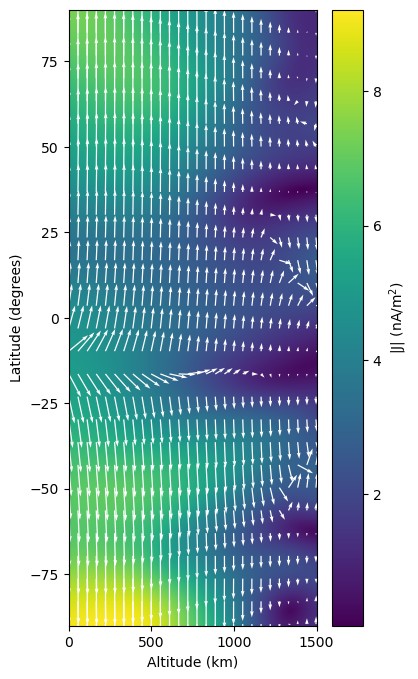

In [7]:

J_flat = np.sqrt(data['Jx'].values**2 + data['Jy'].values**2 + data['Jz'].values**2)
# cmap = cmc.imola()

lat, alt = data['lat'].values, data['alt'].values
lat_unique = np.unique(lat)[::-1]
alt_unique = np.unique(alt)
n_lat = len(lat_unique)
n_alt = len(alt_unique)
J_mesh = J_flat.reshape((n_lat, n_alt))

lat_edges = np.concatenate(([lat_unique[0] - (lat_unique[1]-lat_unique[0])/2],
                            (lat_unique[:-1] + lat_unique[1:])/2,
                            [lat_unique[-1] + (lat_unique[-1]-lat_unique[-2])/2]))
alt_edges = np.concatenate(([alt_unique[0] - (alt_unique[1]-alt_unique[0])/2],
                            (alt_unique[:-1] + alt_unique[1:])/2,
                            [alt_unique[-1] + (alt_unique[-1]-alt_unique[-2])/2]))


plt.figure(figsize=(4,8))
pcm = plt.pcolormesh(alt_edges, lat_edges, J_mesh,  shading='auto')
plt.colorbar(pcm, label='|J| (nA/m$^2$)')
plt.xlabel('Altitude (km)')
plt.ylabel('Latitude (degrees)')

plt.savefig(pathoutput+f'/J_magnitude_profile_lon_{lon}deg{filetype}', dpi=300, bbox_inches='tight')


# quiver plot of J vector field
step = 35
Jr_mesh = data['Jr'].values.reshape((n_lat, n_alt))
Jt_mesh = data['Jt'].values.reshape((n_lat, n_alt))
X, Y = np.meshgrid(alt_unique, lat_unique)

# randomly select points (one in step):
# indices = np.arange(0, n_lat*n_alt)
# indices = np.random.choice(indices, size=(n_lat//step)*(n_alt//step), replace=False)
# mask = np.zeros((n_lat, n_alt), dtype=bool)
# X_masked, Y_masked, Jr_masked, 

# Jt_mesh = Jt_mesh[::-1, :]
plt.quiver(X[::step, ::step], Y[::step, ::step], Jr_mesh[::step, ::step], -Jt_mesh[::step, ::step], color='white', scale=40, width=0.005, angles='xy')

plt.savefig(pathoutput+f'/J_quiver_magnitude_profile_lon_{lon}deg{filetype}', dpi=300, bbox_inches='tight')

In [ ]:
k_start = 1
k_stop = 22
lon = 0
model_name = f"PINN_MSO_ensemble_models_{k_start}to{k_stop}_lon_{lon}deg_profile_gen2"
pathinput = "predictions/"+model_name+".csv"
data = pd.read_csv(pathinput, header=0)
print(data.alt.describe())
data = data[data['alt']>=120]
print('')
print(data.alt.describe())


count    898704.000000
mean        750.000000
std         433.469947
min           0.000000
25%         375.000000
50%         750.000000
75%        1125.000000
max        1500.000000
Name: alt, dtype: float64

count    826656.000000
mean        810.190074
std         398.719171
min         120.380130
25%         465.285155
50%         810.189940
75%        1155.095200
max        1500.000000
Name: alt, dtype: float64


In [9]:
def plot_MSO_plane(x_axis, y_axis, quiver=1, cut_out=1):

    k_start = 1
    k_stop = 22
    pathoutput = f'figures/profiles/PINN_MSO_ensemble_models_{k_start}to{k_stop}_profiles_gen2'
    os.makedirs(pathoutput, exist_ok=True)
   
    if (x_axis != 'Y') & (y_axis != 'Y'): # XZ plane
        lon1, lon2 = 180, 0
    elif (x_axis != 'X') & (y_axis != 'X'): # YZ plane
        lon1 = 270
        lon2 = 90
    elif (x_axis != 'Z') & (y_axis != 'Z'): # XY plane
        lon1, lon2 = 180, 0

    def load_df(lon):
        model_name = f"PINN_MSO_ensemble_models_{k_start}to{k_stop}_lon_{lon}deg_profile_gen2_1500km"
        pathinput = "predictions/"+model_name+".csv"
        data = pd.read_csv(pathinput, header=0)
        return data

    data1 = load_df(lon1)
    # print(len(data1))
    # data1 = data1[data1.lat != -90]
    # print(len(data1))
    data2 = load_df(lon2)
    data = pd.concat([data1,data2])

    if cut_out:
        data = data[data['alt']>=200]

    
    Rm = 3393.5 # km
    r_km = data.alt.values + Rm

    colat_rad = np.deg2rad(90 - data.lat.values)
    lon_rad = np.deg2rad(data.lon.values)
    x,y,z = utils.spherical_to_cartesian_np(r_km, colat_rad, lon_rad)
    x/=Rm
    y/=Rm
    z/=Rm


    J = np.sqrt(data['Jx'].values**2 + data['Jy'].values**2 + data['Jz'].values**2)
    # J = data['Jx'].values


    plt.figure(figsize=(8,6))
    x_planet = np.arange(-1,1+0.0001,0.0001)
    y_planet = np.sqrt(1-x_planet**2)
    plt.plot(x_planet,y_planet,color='k')
    plt.plot(x_planet,-y_planet,color='k')

    plt.axis('equal')
    plt.xlabel(x_axis+r'$_{\text{MSO}}$')
    plt.ylabel(y_axis+r'$_{\text{MSO}}$')
    # lim = [-3,3]
    # plt.xlim(lim)
    # plt.ylim(lim)

    # indices = np.random.choice(a=len(x), size = int(0.0005*len(x)), replace=False)
    indices = np.random.choice(a=len(x), size = int(0.0006*len(x)), replace=False)
    x_quiver, y_quiver, z_quiver = x[indices], y[indices], z[indices]
    Jx, Jy, Jz = data['Jx'].values, data['Jy'].values, data['Jz'].values
    Jx_quiver, Jy_quiver, Jz_quiver = Jx[indices], Jy[indices], Jz[indices]

    if (x_axis != 'Y') & (y_axis != 'Y'): # XZ plane
        plt.scatter(x=x,y=z,c=J)
        plt.colorbar(label='|J| (nA/m$^2$)')
        plt.fill_between(x_planet, -y_planet, y_planet, where=(x_planet>0),  color='lightgray')
        plt.fill_between(x_planet, -y_planet, y_planet, where=(x_planet<=0), color='k')
        if quiver:
            plt.quiver(x_quiver, z_quiver, Jx_quiver, Jz_quiver, color='white', scale=100, width=0.002, angles='xy')
    elif (x_axis != 'X') & (y_axis != 'X'): # YZ plane
        plt.scatter(x=y,y=z,c=J)
        plt.colorbar(label='|J| (nA/m$^2$)')
        plt.fill_between(x_planet, -y_planet, y_planet,  color='lightgray')
        if quiver:
            plt.quiver(y_quiver, z_quiver, Jy_quiver, Jz_quiver, color='white', scale=100, width=0.002, angles='xy')
    elif (x_axis != 'Z') & (y_axis != 'Z'): # XY plane
        plt.fill_between(x_planet, -y_planet, y_planet, where=(x_planet>0),  color='lightgray')
        plt.fill_between(x_planet, -y_planet, y_planet, where=(x_planet<=0), color='k')
        plt.scatter(x=x,y=y,c=J)
        plt.colorbar(label='|J| (nA/m$^2$)')
    
    plt.tight_layout()

    if quiver:
        quiver_str = '_quiver'
    else:
        quiver_str = ''
    if cut_out:
        cut_str = '_nointerp'
    else:
        cut_str = ''

    plt.savefig(pathoutput+'/J'+quiver_str+cut_str+'_'+x_axis+y_axis+'plane.png',dpi=300)
    plt.close()

    # plt.show()



In [10]:
plot_MSO_plane('Y','Z',1,1)

In [5]:
plot_MSO_plane('X','Z',1,1)